# Automated IT Support Ticket Intelligence Analysis

## Project Overview

This project analyzes IT support tickets to identify patterns in request types, priority levels, and operational queues.  
The goal is to highlight recurring issues, understand high-priority ticket behavior, and provide insights that could improve ticket prioritization and IT support workflows.

### Objectives

- Analyze ticket metadata and tagging structure
- Identify patterns in high-priority requests
- Highlight systemic issues in IT support queues
- Provide insights for better prioritization and risk management

In [1]:
# !pip install kaggle

import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase, HandlerLineCollection
from matplotlib.collections import LineCollection
import seaborn as sns
import math
import numpy as np
import shutil

# Loading and Cleaning Data

In [4]:
# Kaggle -> Account -> API
# Scroll down to Legacy API Key
# Click "Create New API Key"
# This will download kaggle.json file automatically
# File will contain username and key

# Your Kaggle credentials
kaggle_json = {
    "username": "loisrandolph",
    "key": "157a0e53a6513cf87a7dc717fa7edfcd"
}

# Ensure the .kaggle folder exists
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Write kaggle.json
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_json, f)

print("kaggle.json created successfully")


# Create data/raw inside the current folder
os.makedirs("data/raw", exist_ok=True)
print("data/raw folder is ready")


csv_path = "C:/Users/loisr/Automated-IT-Support-Ticket-Intelligence/data/raw/dataset-tickets-multi-lang-4-20k.csv"
df = pd.read_csv(csv_path)
df.head()



# Checking for missing values/NA
missing_counts = df.isna().sum()
print("Missing values per column:\n", missing_counts)


# Keeping only columns with missing values 
missing_counts = df.isna().sum() 
missing_cols = missing_counts[missing_counts > 0].index.tolist()
print("Columns with missing values:\n", missing_cols)


# For each column with missing values
for col in missing_cols:
    # Replace NaN with "missing"
    df[col] = df[col].apply(lambda x: x if pd.notna(x) else "missing")
    
    # Get unique values including "missing"
    unique_vals = df[col].unique().tolist()
    
    # Count missing entries
    missing_count = (df[col] == "missing").sum()
    total_count = len(df)
    
    # Print summary
    print(f"\nColumn: {col}")
    print(f"Unique values (including 'missing'): {unique_vals[:10]}...")  # show first 10 only
    print(f"Missing entries: {missing_count} ({missing_count/total_count:.2%})")


# Threshold for categorical-like columns (adjust as needed)
max_unique_for_cat = 10

# Prepare summary list
summary = []

for col in missing_cols:
    
    # Get all unique values, including 'missing'
    unique_vals = df[col].unique().tolist()
    n_unique = len(unique_vals)
    
    # Determine if categorical-like
    is_categorical = n_unique <= max_unique_for_cat
    
    # Count missing entries (now represented as 'missing')
    missing_count = (df[col] == "missing").sum()
    total_count = len(df)
    
    # Append to summary
    summary.append({
        'Column': col,
        'Num Unique (including missing)': n_unique,
        '% Missing': missing_count/total_count,
        'Categorical-Like': is_categorical,
        'Unique Values': unique_vals
    })

# Convert summary to DataFrame for easy viewing
summary_df = pd.DataFrame(summary)
summary_df


# main_folder = "Automated-IT-Support-Ticket-Intelligence"
# os.makedirs(main_folder, exist_ok=True)
# Moving 'data' folder inside main_folder
# shutil.move("data", os.path.join(main_folder, "data"))
# Creating src folder inside main project folder
# os.makedirs(os.path.join(main_folder, "src"), exist_ok=True)


# Moving files inside main project folder
# current_path = r"C:\01_data_integration.ipynb"
# target_folder = r"C:\Automated-IT-Support-Ticket-Intelligence\src"
# target_path = os.path.join(target_folder, "01_data_integration.ipynb")

# shutil.move(current_path, target_path)
# print(f"File moved to: {target_path}")

kaggle.json created successfully
data/raw folder is ready
Missing values per column:
 subject      1461
body            2
answer          4
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          46
tag_3          95
tag_4        1539
tag_5        6909
tag_6       12649
tag_7       16072
tag_8       18093
dtype: int64
Columns with missing values:
 ['subject', 'body', 'answer', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

Column: subject
Unique values (including 'missing'): ['Unvorhergesehener Absturz der Datenanalyse-Plattform', 'Customer Support Inquiry', 'Data Analytics for Investment', 'Krankenhaus-Dienstleistung-Problem', 'Security', 'Concerns About Securing Medical Data on 2-in-1 Convertible Laptop with Norton 360', 'Ratung für Sicherung medizinischer Daten in HubSpot CRM PostgreSQL-Umgebungen', 'Problem with Integration', 'Assistance Request', 'Support Request']...
Missing entries: 1461 (7.31%)

Column: body
Uniq

,Column,Num Unique (including missing),% Missing,Categorical-Like,Unique Values
0,subject,18540,0.07305,False,[Unvorhergesehener Absturz der Datenanalyse-Pl...
1,body,19999,0.00010,False,[Die Datenanalyse-Plattform brach unerwartet a...
2,answer,19997,0.00020,False,[Ich werde Ihnen bei der Lösung des Problems h...
3,tag_2,205,0.00230,False,"[Technical, Sales, Product, Breach, Customer, ..."
4,tag_3,345,0.00475,False,"[Bug, IT, Guidance, Login, Compliance, Feature..."
5,tag_4,482,0.07695,False,"[Hardware, Tech Support, Documentation, Mainte..."
6,tag_5,579,0.34545,False,"[Resolution, missing, Performance, Incident, D..."
7,tag_6,567,0.63245,False,"[Outage, missing, Feature, Resolution, Guidanc..."
8,tag_7,493,0.80360,False,"[Documentation, missing, Feedback, Update, Vir..."
9,tag_8,387,0.90465,False,"[missing, Reference Number, Encryption, Incide..."


# Data Quality Assessment

Categorical-like columns: ['type', 'queue', 'priority', 'language']
Continuous-like columns: ['subject', 'body', 'answer', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


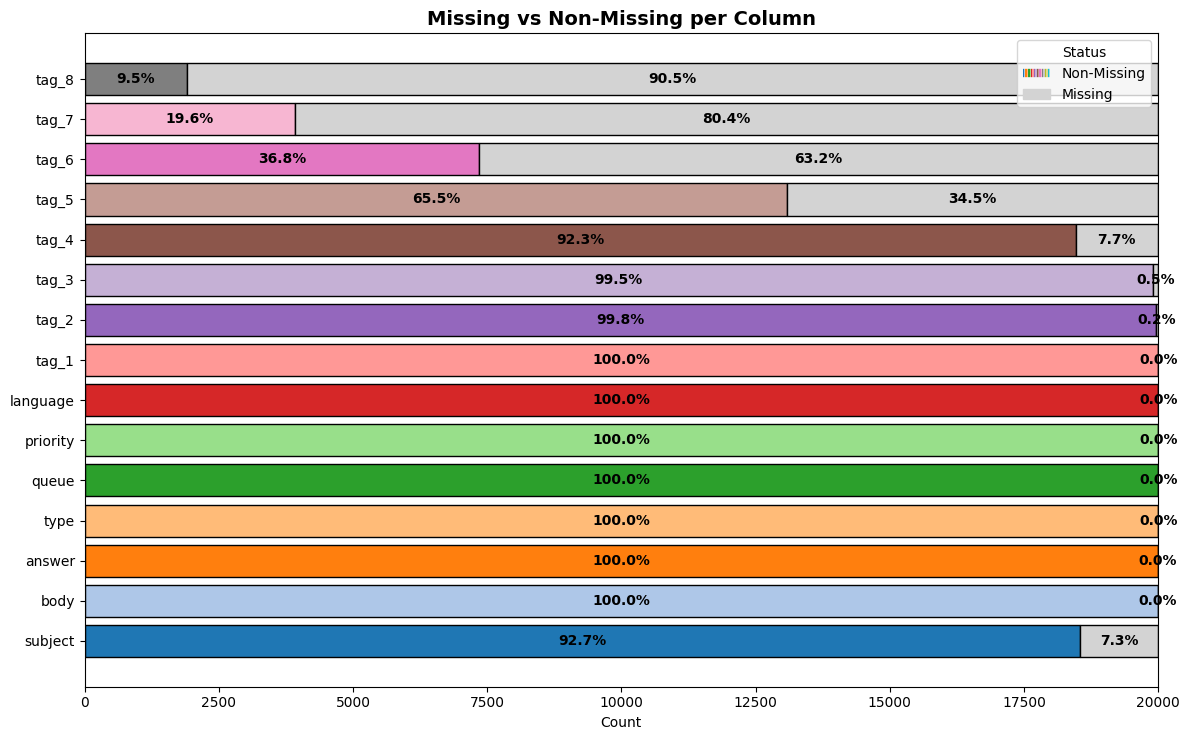

In [6]:
# Loading processed data
processed_df = pd.read_csv(r"C:\Users\loisr\Automated-IT-Support-Ticket-Intelligence\data\processed\df_integrated.csv")
processed_summary_df = pd.read_csv(r"C:\Users\loisr\Automated-IT-Support-Ticket-Intelligence\data\processed\summary_csv")


# Threshold for categorical-like columns
max_unique_for_cat = 10  # adjust if needed

categorical_cols = []
continuous_cols = []

for col in processed_df.columns:
    n_unique = processed_df[col].nunique()
    if n_unique <= max_unique_for_cat:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)

print("Categorical-like columns:", categorical_cols)
print("Continuous-like columns:", continuous_cols)


# Count "missing" entries for each column
missing_summary = {col: (processed_df[col] == "missing").sum() for col in processed_df.columns}
missing_df = pd.DataFrame.from_dict(missing_summary, orient='index', columns=['Missing Count'])
missing_df['Non-Missing Count'] = len(processed_df) - missing_df['Missing Count']
missing_df['% Missing'] = missing_df['Missing Count'] / len(processed_df)
missing_df.sort_values('% Missing', ascending=False)

plot_df = missing_df[['Non-Missing Count','Missing Count']]

colors = plt.cm.tab20.colors 
n_cols = len(plot_df)

# Prepare a color list for each non-missing bar
non_missing_colors = [colors[i % len(colors)] for i in range(n_cols)]
missing_color = 'lightgrey'  # keep missing grey

# ---------------------------
# Create a rainbow patch
# ---------------------------
# Make a small gradient image for the legend
gradient = np.linspace(0, 1, 256).reshape(1, -1)  # 1x256 array
cmap = plt.cm.tab20  # same colormap as your bars

class HandlerColormap(HandlerBase):
    def __init__(self, cmap, **kw):
        self.cmap = cmap
        super().__init__(**kw)
    def create_artists(self, legend, orig_handle,
                       x0, y0, width, height, fontsize, trans):
        import matplotlib.patches as patches
        # rectangle filled with colormap gradient
        rect = patches.Rectangle([x0, y0], width, height, transform=trans,
                                 color='none')
        rect.set_facecolor(self.cmap(0.5))  # center color as approximation
        return [rect]
        

class HandlerColorLineCollection(HandlerLineCollection):
    def create_artists(self, legend, artist, xdescent, ydescent,
                       width, height, fontsize, trans):
        import numpy as np
        from matplotlib.collections import LineCollection

        x = np.linspace(0, width, self.get_numpoints(legend)+1)
        y = np.zeros(self.get_numpoints(legend)+1) + height/2. - ydescent
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap=artist.cmap, transform=trans)
        lc.set_array(x)
        lc.set_linewidth(artist.get_linewidth())

        return [lc]
        

# Create legend handles
rainbow_patch = LineCollection([[(0,0),(1,0)]], cmap=cmap, linewidth=6)
rainbow_patch.set_array(np.linspace(0,1,10))
missing_patch = mpatches.Patch(color='lightgrey', label='Missing')


fig, ax = plt.subplots(figsize=(12, max(6, n_cols*0.5)))

# Plot each bar individually so we can assign unique colors to non-missing
for i, col in enumerate(plot_df.index):
    counts = plot_df.loc[col]
    ax.barh(y=i, width=counts['Non-Missing Count'], color=non_missing_colors[i], edgecolor='black', label='Non-Missing' if i==0 else "")
    ax.barh(y=i, width=counts['Missing Count'], left=counts['Non-Missing Count'], color=missing_color, edgecolor='black', label='Missing' if i==0 else "")

    # Annotate percentages
    total = counts.sum()
    ax.text(counts['Non-Missing Count']/2, i, f'{counts["Non-Missing Count"]/total*100:.1f}%', 
            ha='center', va='center', color='black', fontweight='bold')
    ax.text(counts['Non-Missing Count'] + counts['Missing Count']/2, i, f'{counts["Missing Count"]/total*100:.1f}%', 
            ha='center', va='center', color='black', fontweight='bold')

ax.set_yticks(range(n_cols))
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Count")
ax.set_title("Missing vs Non-Missing per Column", fontsize=14, fontweight='bold')

# Show only one legend per category
ax.legend(handles=[rainbow_patch, missing_patch],
          labels=['Non-Missing', 'Missing'],
          handler_map={rainbow_patch: HandlerColorLineCollection(numpoints=100)},
          title='Status',
          loc='upper right')
plt.tight_layout()
plt.show()

# Ticket Tag Analysis

## Tags provide insight into the nature of support requests. 

## This section explores the frequency of request types associated with each tag.

C:\Users\loisr\AppData\Local\Temp\ipykernel_13204\476837335.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\loisr\AppData\Local\Temp\ipykernel_13204\476837335.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\loisr\AppData\Local\Temp\ipykernel_13204\476837335.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\loisr\AppData\Local\Temp\ipykernel_13204\476837335.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variabl

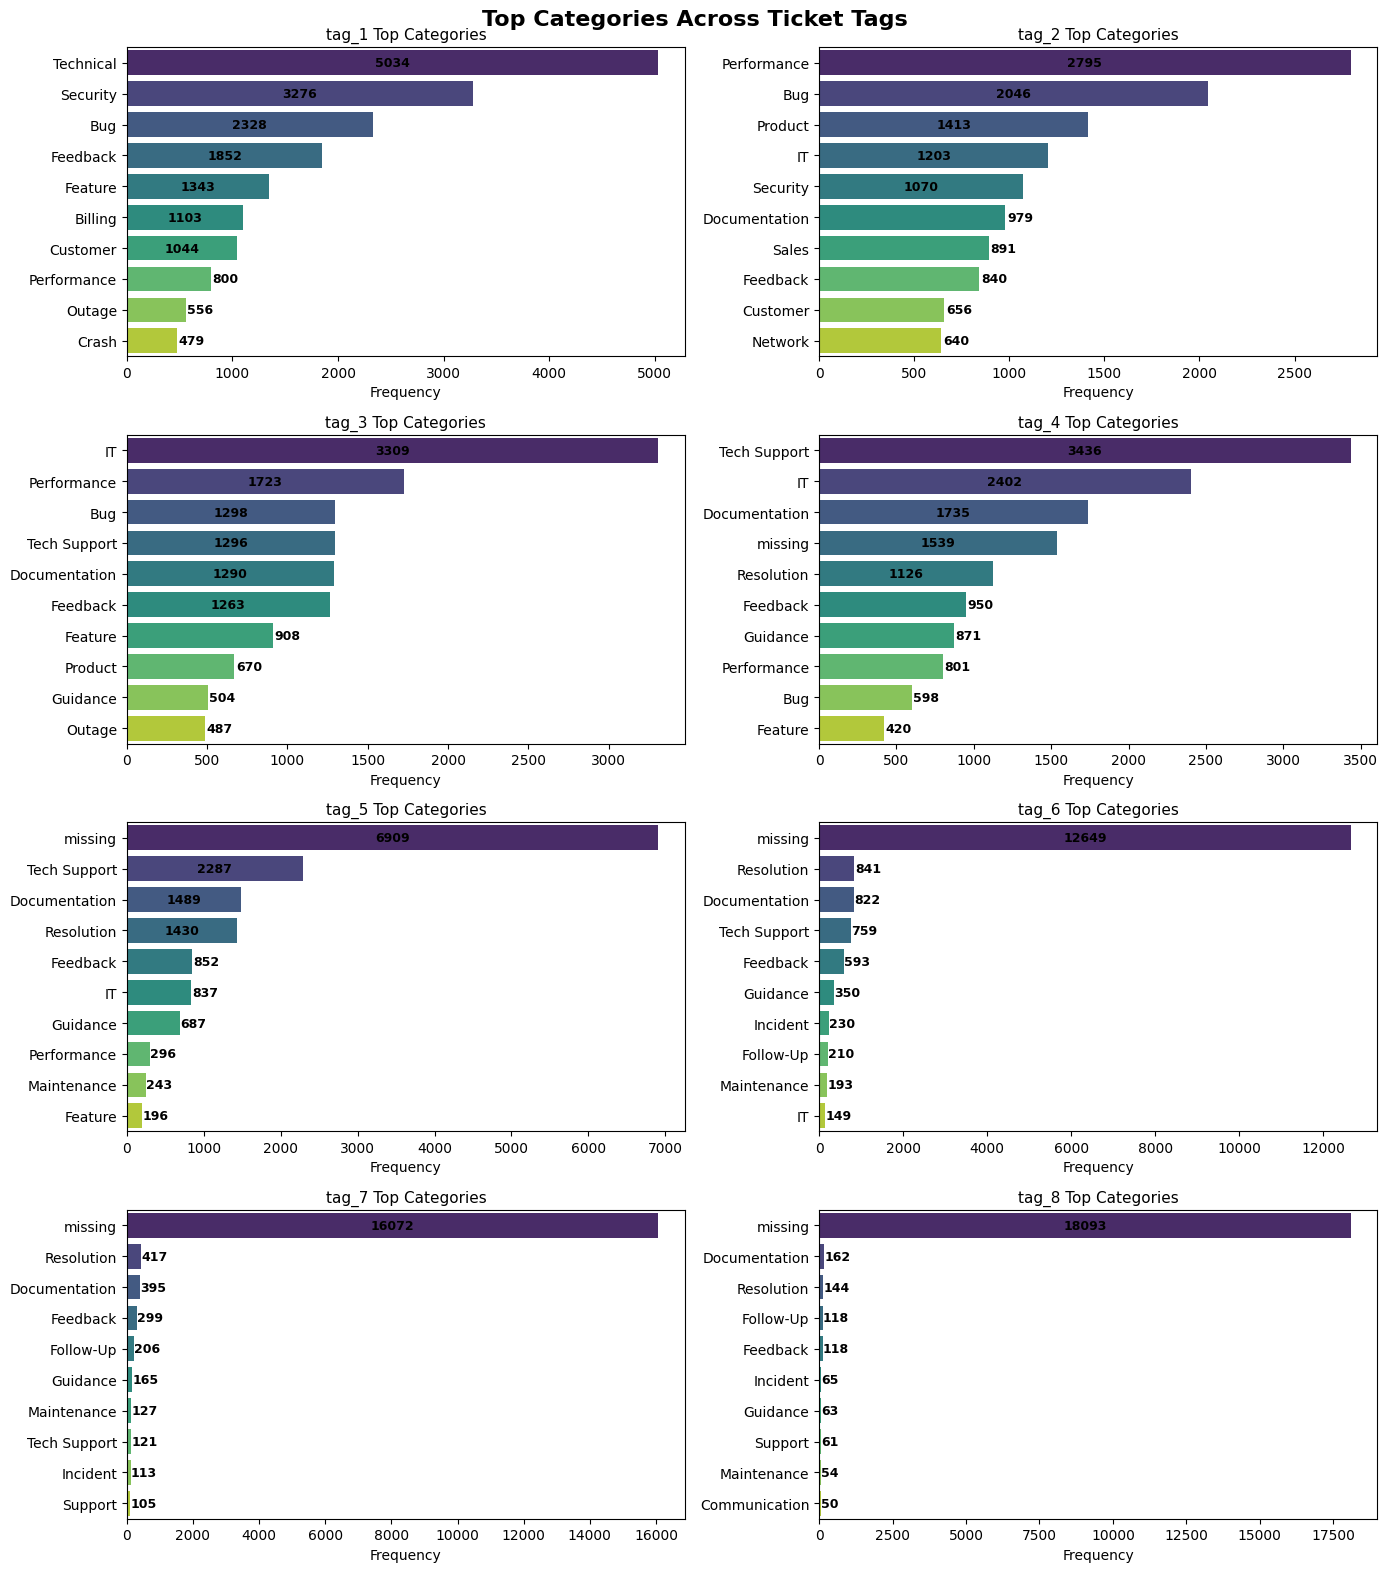

In [21]:
tag_cols = [f"tag_{i}" for i in range(1,9)]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(tag_cols):
    value_counts = processed_df[col].fillna("missing").value_counts().head(10)

    ax = sns.barplot(
        x=value_counts.values,
        y=value_counts.index,
        palette="viridis",
        ax=axes[i]
    )

    # Add labels to bars
    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2

            if width > 1000: # text will be centered in larger bars
                ax.text(width/2, y, f'{int(width)}',
                        ha='center', va='center',
                        color='black', fontsize=9, fontweight='bold')
            else: # text will be outside smaller bars
                ax.text(width + 10, y, f'{int(width)}',
                        ha='left', va='center',
                        color='black', fontsize=9, fontweight='bold')

    axes[i].set_title(f"{col} Top Categories", fontsize=11)
    axes[i].set_xlabel("Frequency")
    axes[i].set_ylabel("")

plt.suptitle("Top Categories Across Ticket Tags", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Key Insights

## Common ticket tags reveal recurring categories of technical (e.g., software or hardware issues) support issues.

## The remaining tags tag_5 - tag_8 had mostly "missing" appearing as the most frequent value suggesting that ticket classification primarily relies on the first few tag fields and tag_5 - tag_8 columns contribute little additional categorization. This is assuming a single ticket request is associated with multiple tags.

# Ticket Analysis by Priority | Queue Risk Analysis

## Understanding the distribution of ticket types helps identify the most common forms of support activity. 

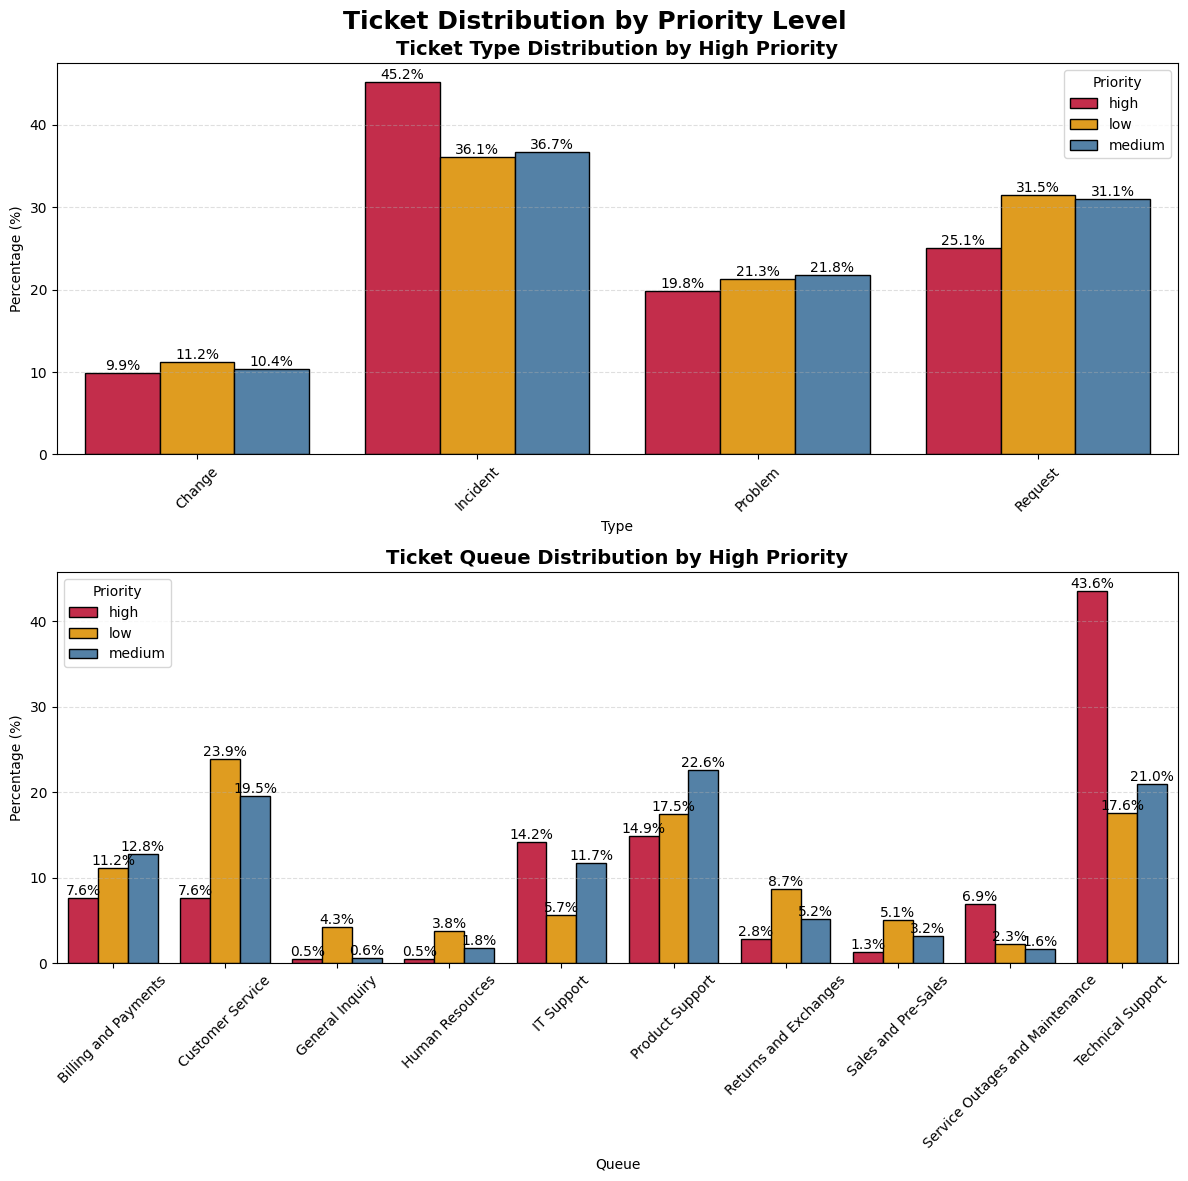

In [24]:
# Group tickets by priority
# Ensure priority column exists and is standardized
processed_df['priority'] = processed_df['priority'].str.lower().fillna('unknown')


high_priority = processed_df[processed_df['priority'] == 'high']
medium_priority = processed_df[processed_df['priority'] == 'medium']
low_priority = processed_df[processed_df['priority'] == 'low']



# How do different types of requests and queues relate to priority, and what does that imply about resource allocation?
# Goal: Identify patterns in high-priority requests

# Which IT support tags correspond to critical tickets, and can they be clustered to understand systemic issues?
# Goal: Highlight recurring problems or bottlenecks

# Are there areas where tickets are mis-prioritized relative to business impact
# Goal: Suggest rules for better prioritization and risk management


def get_freq_by_priority(df, col):
    freq = df.groupby(['priority', col]).size().reset_index(name='count')
    freq['percent'] = freq.groupby('priority')['count'].transform(lambda x: x / x.sum() * 100)
    return freq

 
type_freq = get_freq_by_priority(processed_df, 'type')
queue_freq = get_freq_by_priority(processed_df, 'queue')



def plot_freq_multiple(freq_list, col_list, title_list):
     """
    freq_list: list of frequency dataframes
    col_list: list of column names for x-axis
    title_list: list of titles for each subplot
    """
    
    n = len(freq_list)
    fig, axs = plt.subplots(n, 1, figsize=(12, 6*n))

    if n == 1:
        axs = [axs]

    for i in range(n):
        ax = axs[i]

        sns.barplot(
            data=freq_list[i],
            x=col_list[i],
            y='percent',
            hue='priority',
            palette=['crimson', 'orange', 'steelblue'],
            ax=ax,
            edgecolor='black'
        )

        ax.set_title(title_list[i], fontsize=14, fontweight='bold')
        ax.set_ylabel('Percentage (%)')
        ax.set_xlabel(col_list[i].capitalize())
        plt.setp(ax.get_xticklabels(), rotation=45)

        ax.grid(axis='y', linestyle='--', alpha=0.4)

        # Value labels
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(
                    f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center',
                    va='bottom',
                    fontsize=10
                )

        ax.legend(title="Priority")

    fig.suptitle(
        "Ticket Distribution by Priority Level",
        fontsize=18,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


freq_list = [type_freq, queue_freq]
col_list = ['type', 'queue']
title_list = [
    'Ticket Type Distribution by High Priority',
    'Ticket Queue Distribution by High Priority'
]

plot_freq_multiple(freq_list, col_list, title_list)

# Key Insights

## Analysis if ticket priorities indicates that "Incident-type" requests make up the largest proportion of high-priority tickets, while the "Technical Support" queue handles the majority of these urgent issues. 

## This pattern suggests that high-priority tickets are largely driven by operational disruptions that require immediate tecnical intervention, highlighting the importance of proficient staff and resources within technical support teams.